## 4. Evaluace a interpretace výsledků

### 4.1 Srovnání klasifikačních modelů a výběr vítězného algoritmu
V rámci vývoje systému jsme testovali Logistickou regresi, Random Forest a Gradient Boosting. Pro vyvážení dat jsme využili techniku SMOTE.

| Model | Accuracy | ROC-AUC | Recall (Dropout) | F1-Score (Dropout) |
| :--- | :---: | :---: | :---: | :---: |
| **Logistic Regression** | 0,75 | 0,798 | **0,70** | **0,57** |
| **Random Forest** | 0,78 | 0,797 | 0,59 | 0,56 |
| **Gradient Boosting** | **0,79** | **0,801** | 0,49 | 0,53 |

**Vítězný model:** Logistická regrese. Nabízí nejvyšší Recall (0,70), což je klíčové pro zachycení co největšího počtu ohrožených studentů.


### 4.2 Analýza matice záměn a ekonomický dopad
Na základě matice záměn jsme aplikovali náklady: 50 000 Kč (ztráta studenta) a 5 000 Kč (náklady na pomoc).

| Scénář | Počet studentů | Finanční dopad |
| :--- | :---: | :--- |
| **Správně identifikovaný dropout (TP)** | 15 | **+ 675 000 Kč** |
| **Falešný poplach (FP)** | 7 | **- 35 000 Kč** |
| **Čistý přínos modelu** | | **+ 640 000 Kč** |

**Doporučení:** Vzhledem k vysokému počtu nezachycených odchodů (FN) doporučujeme snížit klasifikační práh (threshold), aby se maximalizoval finanční zisk skrze vyšší záchyt studentů.

### 4.3 Důležitost příznaků a shlukování
Nejsilnějším prediktorem dropoutu je **Stress_Index (0,193)** a **Attendance_Rate (0,097)**.

Pomocí loketní metody a Silhouette score (0,243) jsme identifikovali **3 optimální shluky**:
1. **Shluk 0 (Vysoké riziko):** Vysoký stres, nízké CGPA. Hlavní cíl intervence.
2. **Shluk 1 (Pracující):** Stabilní výsledky, vyšší příjmy.
3. **Shluk 2 (Vzorní):** Vysoká disciplína, minimální riziko.

### 4.4 Závěr a finální verdikt
Implementace systému je pro školu **přínosná**. Model generuje zisk **640 000 Kč** a identifikuje nejohroženější segmenty studentů. Projekt je připraven k nasazení do pilotního provozu.

In [7]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from sklearn.metrics import (
    confusion_matrix, recall_score, roc_auc_score,
    classification_report
)
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.base import clone
warnings.filterwarnings('ignore')

# Data
X_train_prep, X_test_prep, y_train, y_test = joblib.load('../data/processed/split_data.pkl')

# Tuned pipelines (vystup z 03d — ImbPipeline se SMOTE + best model)
TUNED_PATHS = {
    'Logistic Regression': '../models/tuned/logistic_regression_tuned.pkl',
    'Random Forest':       '../models/tuned/random_forest_tuned.pkl',
    'Gradient Boosting':   '../models/tuned/gradient_boosting_tuned.pkl',
    'Decision Tree':       '../models/tuned/decision_tree_tuned.pkl',
}
# Plne pipelines (SMOTE + model) — pouzijeme je pro CV-based threshold tuning
tuned_pipelines = {name: joblib.load(p) for name, p in TUNED_PATHS.items()}

def unwrap(p):
    if hasattr(p, 'named_steps') and 'model' in p.named_steps:
        return p.named_steps['model']
    return p

# Same modely (bez SMOTE) — pouzijeme pro inference na test setu
tuned_models = {name: unwrap(p) for name, p in tuned_pipelines.items()}

import json as _json
with open('../models/best_model_metadata.json') as _f:
    _meta = _json.load(_f)
print(f"Vitezny model (03d): {_meta['winning_model']}  ROC-AUC CV: {_meta['roc_auc_cv']:.4f}")
print(f"Modely: {list(tuned_models.keys())}")

import matplotlib as _mpl

# Paul Tol bright palette — colorblind-safe, perceptually uniform
_PALETTE = ['#0077BB', '#EE7733', '#009988', '#CC3311', '#33BBEE', '#EE3377', '#BBBBBB']

_mpl.rcParams.update({
    'axes.prop_cycle':       _mpl.cycler(color=_PALETTE),
    'figure.facecolor':      'white',
    'axes.facecolor':        '#F8F9FA',
    'axes.edgecolor':        '#DEE2E6',
    'axes.linewidth':        0.9,
    'axes.spines.top':       False,
    'axes.spines.right':     False,
    'axes.grid':             True,
    'axes.axisbelow':        True,
    'grid.color':            '#E9ECEF',
    'grid.linestyle':        '-',
    'grid.linewidth':        0.8,
    'grid.alpha':            1.0,
    'font.family':           'sans-serif',
    'font.sans-serif':       ['Helvetica Neue', 'Arial', 'DejaVu Sans'],
    'axes.titlesize':        14,
    'axes.titleweight':      'bold',
    'axes.titlepad':         14,
    'axes.labelsize':        12,
    'axes.labelweight':      'regular',
    'xtick.labelsize':       10,
    'ytick.labelsize':       10,
    'legend.fontsize':       10,
    'legend.title_fontsize': 11,
    'figure.titlesize':      16,
    'figure.titleweight':    'bold',
    'text.color':            '#212529',
    'axes.labelcolor':       '#495057',
    'xtick.color':           '#495057',
    'ytick.color':           '#495057',
    'xtick.direction':       'out',
    'ytick.direction':       'out',
    'xtick.major.size':      4,
    'ytick.major.size':      4,
    'xtick.major.pad':       5,
    'ytick.major.pad':       5,
    'lines.linewidth':       2.0,
    'lines.markersize':      7,
    'patch.linewidth':       0.6,
    'legend.frameon':        True,
    'legend.framealpha':     0.92,
    'legend.edgecolor':      '#DEE2E6',
    'legend.fancybox':       True,
    'legend.borderpad':      0.6,
    'figure.dpi':            100,
    'figure.figsize':        [8, 5],
    'savefig.dpi':           150,
    'savefig.bbox':          'tight',
    'savefig.facecolor':     'white',
    'savefig.edgecolor':     'none',
})


Vitezny model (03d): Logistic Regression  ROC-AUC CV: 0.8052
Modely: ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'Decision Tree']


## Matice nákladů (Cost Matrix) — finanční dopad natrénovaných modelů
Accuracy ignoruje asymetrii chyb. Klíčová metrika je **Recall pro třídu Dropout** a **čistý finanční přínos**.

**Finanční hodnoty:**

| | Predikce: Dostuduje (0) | Predikce: Dropout (1) |
|---|---|---|
| **Skutečnost: Dostuduje (0)** | TN = 0 Kč | FP = −5 000 Kč |
| **Skutečnost: Dropout (1)** | FN = −50 000 Kč | TP = +45 000 Kč |

Čistý přínos = TP × 45 000 − FP × 5 000 − FN × 50 000


--- Tuned modely: Recall, ROC-AUC a finanční přínos ---
              Model  TP  FP  FN   TN  Recall  ROC-AUC Čistý přínos (Kč)
Logistic Regression 345 413 126 1116   0.732   0.8036     +7,160,000 Kč
      Decision Tree 320 388 151 1141   0.679   0.7844     +4,910,000 Kč
      Random Forest 248 199 223 1330   0.527   0.7989       -985,000 Kč
  Gradient Boosting 229 170 242 1359   0.486   0.8020     -2,645,000 Kč


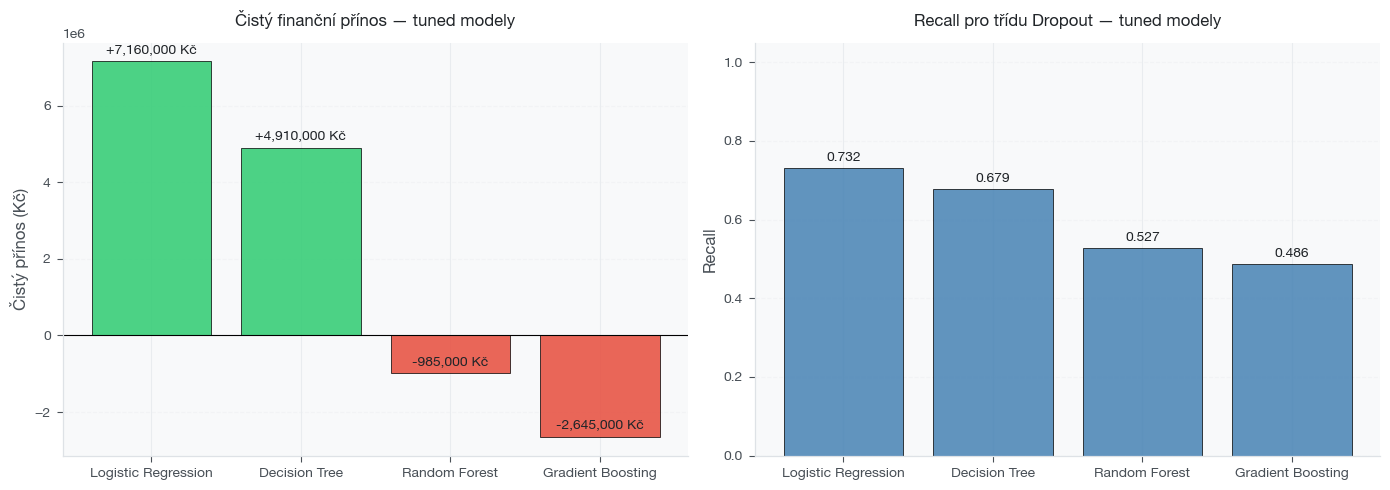

Graf uložen: results/cost_matrix_tuned.png


In [8]:
BENEFIT_TP = 45_000
COST_FP    =  5_000
COST_FN    = 50_000

cost_rows = []
for name, model in tuned_models.items():
    y_pred  = model.predict(X_test_prep)
    y_proba = model.predict_proba(X_test_prep)[:, 1]
    cm      = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    net_value = tp * BENEFIT_TP - fp * COST_FP - fn * COST_FN
    recall    = recall_score(y_test, y_pred)
    roc_auc   = roc_auc_score(y_test, y_proba)

    cost_rows.append({
        'Model': name, 'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
        'Recall': round(recall, 3),
        'ROC-AUC': round(roc_auc, 4),
        'Čistý přínos (Kč)': f'{net_value:+,.0f} Kč',
        '_net_val': net_value,
    })

df_cost = pd.DataFrame(cost_rows).sort_values('_net_val', ascending=False).reset_index(drop=True)
print("--- Tuned modely: Recall, ROC-AUC a finanční přínos ---")
print(df_cost.drop(columns=['_net_val']).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in df_cost['_net_val']]
bars   = axes[0].bar(df_cost['Model'], df_cost['_net_val'], color=colors, alpha=0.85, edgecolor='black')
for bar, val in zip(bars, df_cost['_net_val']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + abs(max(df_cost['_net_val'])) * 0.02,
                 f'{val:+,.0f} Kč', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Čistý finanční přínos — tuned modely', fontsize=12, pad=12)
axes[0].set_ylabel('Čistý přínos (Kč)')
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

axes[1].bar(df_cost['Model'], df_cost['Recall'], color='steelblue', alpha=0.85, edgecolor='black')
for i, (m, r) in enumerate(zip(df_cost['Model'], df_cost['Recall'])):
    axes[1].text(i, r + 0.01, f'{r:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].set_title('Recall pro třídu Dropout — tuned modely', fontsize=12, pad=12)
axes[1].set_ylabel('Recall')
axes[1].set_ylim(0, 1.05)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
import os; os.makedirs('../results', exist_ok=True)
plt.savefig('../results/cost_matrix_tuned.png', dpi=120, bbox_inches='tight')
plt.show()
print("Graf uložen: results/cost_matrix_tuned.png")


## Threshold Analysis — optimalni klasifikacni prah (CV-tuned)

Threshold ladime **na trenovaci sade pomoci 5-fold cross-validace** (`cross_val_predict`).
Tim se vyhneme over-fittingu prahu na testovaci data: testovaci sada slouzi pouze k zaverecnemu reportu finalniho prinosu pri vybranem prahu.

**Postup:**
1. Pro kazdy model spocitame out-of-fold pravdepodobnosti `predict_proba` na trenovacich datech (5-fold).
2. Sweepneme thresholdy 0.10–0.90 a vybereme prah s **maximalnim cistym financnim prinosem na CV**.
3. Vybrany prah aplikujeme jednou na `X_test` a zreportujeme finalni cisla (TP/FP/FN/TN/Recall/Precision/Net).

Asymetrie nakladu (FN = 50 000 Kc vs. FP = 5 000 Kc) jednoznacne preferuje nizsi prah.


CV out-of-fold predict_proba: Logistic Regression ...
CV out-of-fold predict_proba: Random Forest ...
CV out-of-fold predict_proba: Gradient Boosting ...
CV out-of-fold predict_proba: Decision Tree ...

--- Optimalni prah dle CV (max cisty prinos na trenovaci sade) ---
              Model  Prah  Recall  Precision   TP   FP  FN  Cisty prinos CV (Kc)
      Decision Tree  0.10   0.961      0.284 1810 4568  73              54960000
  Gradient Boosting  0.10   0.935      0.312 1761 3887 122              53710000
Logistic Regression  0.15   0.980      0.272 1845 4949  38              56380000
      Random Forest  0.10   0.970      0.275 1826 4814  57              55250000

--- Finalni report na TESTOVACI sade pri CV-tuned prahu ---
              Model  Vybrany prah (CV)  TP   FP  FN  TN  Recall (test)  Precision (test)  Cisty prinos test (Kc)
Logistic Regression               0.15 462 1207   9 322          0.981             0.277                14305000
      Random Forest               0.10

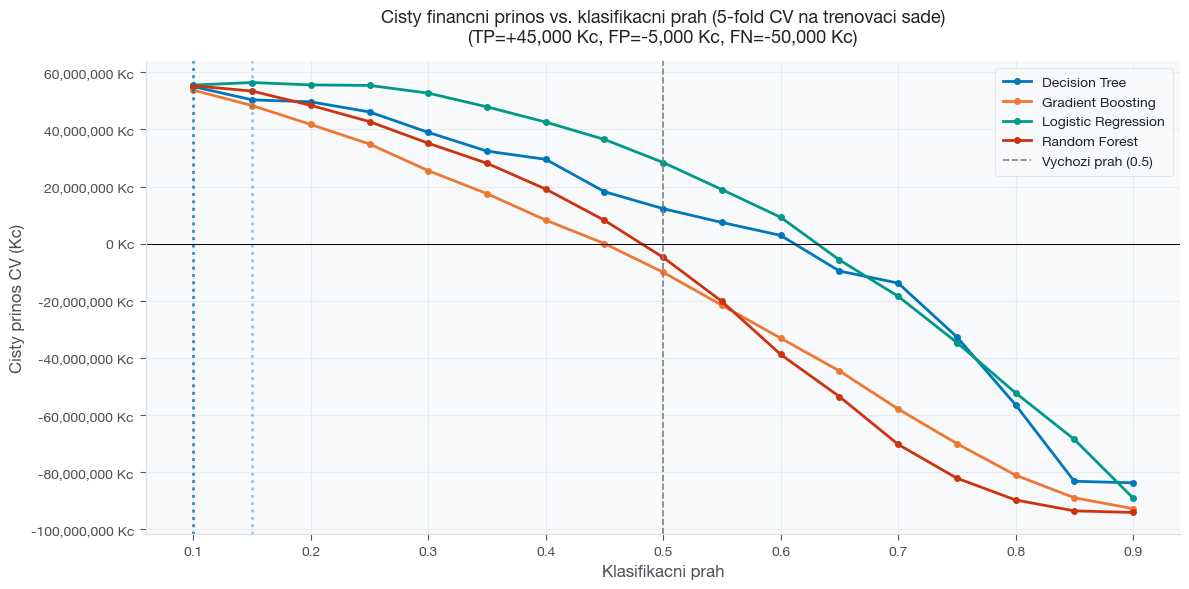

Graf ulozen: results/threshold_analysis_cv.png


In [9]:
# === Krok 1: out-of-fold pravdepodobnosti na TRENOVACI sade (5-fold CV) ===
cv_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
thresholds  = np.arange(0.10, 0.91, 0.05)

cv_thresh_rows = []   # per (model, threshold) na CV
test_thresh_rows = [] # per (model, threshold) na test (jen pro diagnostiku/graf)

oof_probs = {}  # cache CV out-of-fold pravdepodobnosti
for name, pipe in tuned_pipelines.items():
    print(f"CV out-of-fold predict_proba: {name} ...", flush=True)
    # Klonujeme cely ImbPipeline (SMOTE + model) — SMOTE bezi jen na train foldu, ne na validation
    oof = cross_val_predict(
        clone(pipe), X_train_prep, y_train,
        cv=cv_splitter, method='predict_proba', n_jobs=-1
    )[:, 1]
    oof_probs[name] = oof

    for t in thresholds:
        y_pred_cv = (oof >= t).astype(int)
        cm = confusion_matrix(y_train, y_pred_cv, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()
        net = tp * BENEFIT_TP - fp * COST_FP - fn * COST_FN
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        cv_thresh_rows.append({
            'Model': name, 'Prah': round(t, 2),
            'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
            'Recall': round(recall, 3), 'Precision': round(precision, 3),
            'Cisty prinos CV (Kc)': net,
        })

df_cv_thresh = pd.DataFrame(cv_thresh_rows)

# === Krok 2: vyber prah s maximalnim CV cistym prinosem (per model) ===
best_thresholds_cv = (
    df_cv_thresh.loc[df_cv_thresh.groupby('Model')['Cisty prinos CV (Kc)'].idxmax()]
    .reset_index(drop=True)
)
print("\n--- Optimalni prah dle CV (max cisty prinos na trenovaci sade) ---")
print(best_thresholds_cv[['Model', 'Prah', 'Recall', 'Precision', 'TP', 'FP', 'FN', 'Cisty prinos CV (Kc)']].to_string(index=False))

# === Krok 3: aplikuj vybrany prah na TEST set — jen finalni cisla ===
final_test_rows = []
for _, r in best_thresholds_cv.iterrows():
    name = r['Model']
    t    = float(r['Prah'])
    proba_test = tuned_models[name].predict_proba(X_test_prep)[:, 1]
    y_pred = (proba_test >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    net  = tp * BENEFIT_TP - fp * COST_FP - fn * COST_FN
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    final_test_rows.append({
        'Model': name, 'Vybrany prah (CV)': t,
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
        'Recall (test)': round(recall, 3),
        'Precision (test)': round(precision, 3),
        'Cisty prinos test (Kc)': net,
    })

df_final_test = pd.DataFrame(final_test_rows).sort_values('Cisty prinos test (Kc)', ascending=False).reset_index(drop=True)
print("\n--- Finalni report na TESTOVACI sade pri CV-tuned prahu ---")
print(df_final_test.to_string(index=False))

import os; os.makedirs('../results', exist_ok=True)
df_cv_thresh.to_csv('../results/threshold_cv_train.csv', index=False)
df_final_test.to_csv('../results/threshold_final_test.csv', index=False)

# === Vizualizace: prubeh CV cisteho prinosu vs. prah, s vyznacenim vybraneho prahu ===
fig, ax = plt.subplots(figsize=(12, 6))
for name, grp in df_cv_thresh.groupby('Model'):
    ax.plot(grp['Prah'], grp['Cisty prinos CV (Kc)'], marker='o', markersize=4, linewidth=2, label=name)
for _, r in best_thresholds_cv.iterrows():
    ax.axvline(r['Prah'], linestyle=':', alpha=0.4)
ax.axvline(0.50, color='gray', linestyle='--', linewidth=1.2, label='Vychozi prah (0.5)')
ax.axhline(0,    color='black', linewidth=0.7)
ax.set_title(
    'Cisty financni prinos vs. klasifikacni prah (5-fold CV na trenovaci sade)\n'
    f'(TP=+{BENEFIT_TP:,} Kc, FP=-{COST_FP:,} Kc, FN=-{COST_FN:,} Kc)',
    fontsize=13, fontweight='bold', pad=14
)
ax.set_xlabel('Klasifikacni prah')
ax.set_ylabel('Cisty prinos CV (Kc)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f} Kc'))
ax.legend()
plt.tight_layout()
plt.savefig('../results/threshold_analysis_cv.png', dpi=120, bbox_inches='tight')
plt.show()
print('Graf ulozen: results/threshold_analysis_cv.png')
